<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day1_dailychallenges_day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Load and Preprocess the MNIST Dataset

In [8]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)


In [10]:
# Normalize image pixel values to be between 0 and 1
# Reshape the images to have a single channel (grayscale)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255

print(f"Normalized x_train shape: {x_train.shape}")
print(f"Normalized x_test shape: {x_test.shape}")

Normalized x_train shape: (60000, 28, 28, 1)
Normalized x_test shape: (10000, 28, 28, 1)


In [11]:
# Convert labels into one-hot encoded format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f"One-hot encoded y_train shape: {y_train.shape}")
print(f"One-hot encoded y_test shape: {y_test.shape}")

One-hot encoded y_train shape: (60000, 10)
One-hot encoded y_test shape: (10000, 10)


### Display Sample Images (generated by previous prompt)

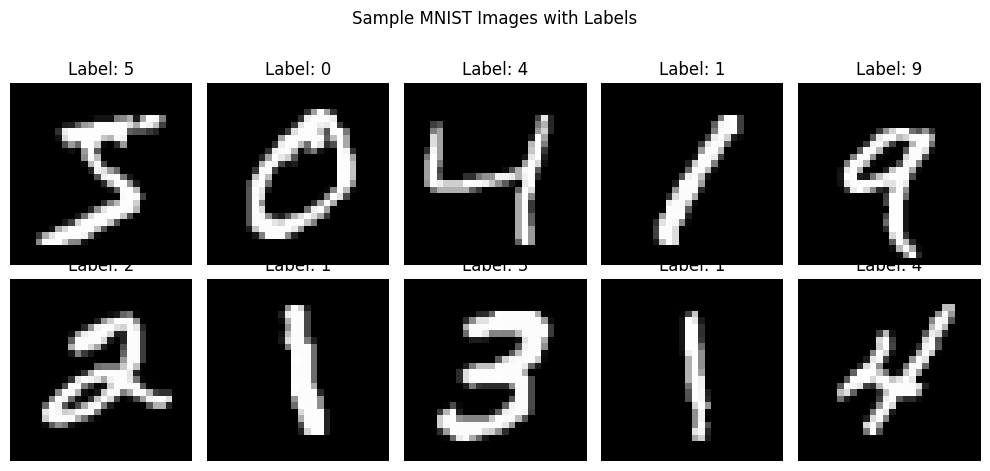

In [12]:
# Display sample images with their corresponding labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    # Convert one-hot encoded label back to integer for display
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Sample MNIST Images with Labels')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2. Build a Fully Connected Neural Network

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Define a sequential model
model = Sequential([
    # Flatten the 28x28 input images into a single vector of 784 elements
    Flatten(input_shape=(28, 28, 1)),
    # Add a first hidden layer with 128 neurons and ReLU activation
    Dense(128, activation='relu'),
    # Add a second hidden layer with 64 neurons and ReLU activation
    Dense(64, activation='relu'),
    # Add an output layer with 10 neurons (for 10 classes) and Softmax activation
    # Softmax is used for multi-class classification to output probabilities
    Dense(10, activation='softmax')
])

# Compile the model
# Optimizer: 'adam' is a popular choice for many tasks
# Loss function: 'categorical_crossentropy' for one-hot encoded labels
# Metrics: 'accuracy' to monitor classification performance
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Neural Network

In [14]:
# Train the neural network
# Fit the model to the training data for 10 epochs
# Use the test set as validation data to track performance during training
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

print("\nTraining complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9281 - loss: 0.2467 - val_accuracy: 0.9616 - val_loss: 0.1271
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9709 - loss: 0.0989 - val_accuracy: 0.9722 - val_loss: 0.0898
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0714 - val_accuracy: 0.9759 - val_loss: 0.0813
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0533 - val_accuracy: 0.9780 - val_loss: 0.0748
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0427 - val_accuracy: 0.9765 - val_loss: 0.0772
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9887 - loss: 0.0344 - val_accuracy: 0.9758 - val_loss: 0.0873
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9908 - loss: 0.0276 - val_accuracy: 0.9772 - val_loss: 0.0785
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9921 - loss: 0.0232 - 

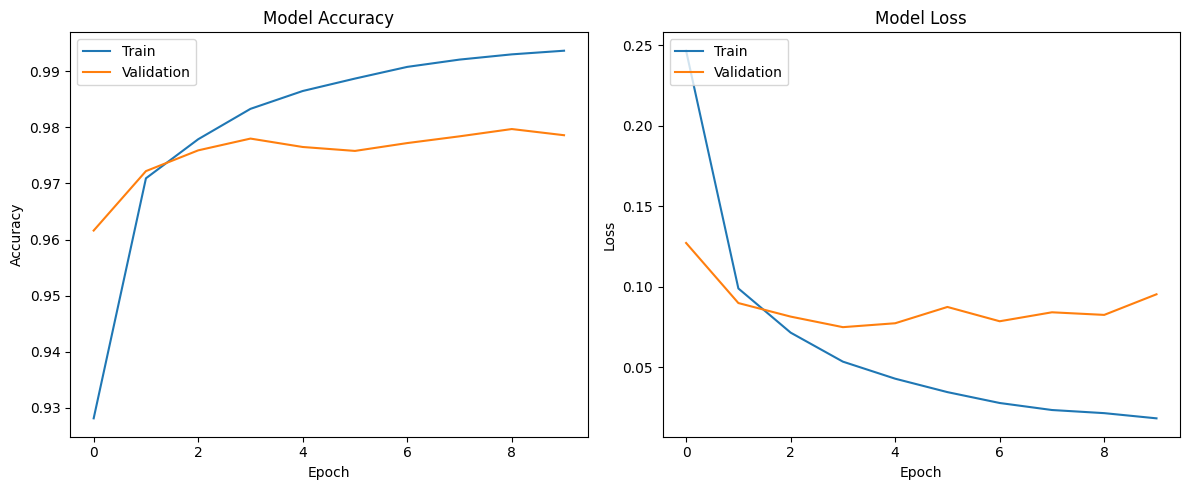

In [15]:
# Observe the loss and accuracy trends over the epochs
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## 4. Evaluate the Model's Performance

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0952
Test Accuracy: 0.9786


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


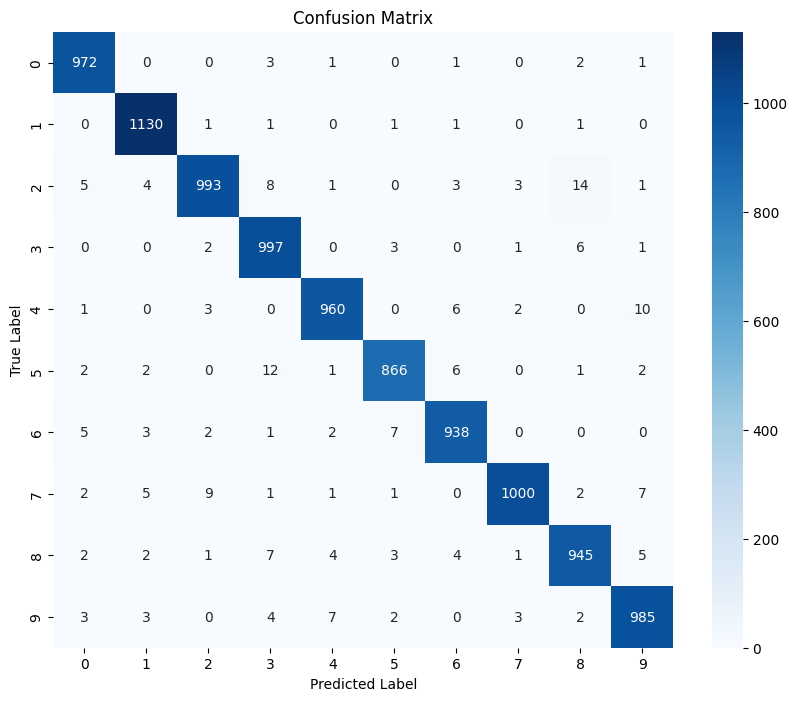

In [17]:
# Make predictions on the test data
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Display a confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Model struggles most with the following digits (least accurate):
Digit 2: Accuracy 0.9622
Digit 8: Accuracy 0.9702
Digit 5: Accuracy 0.9709

Examples of misclassified digits:


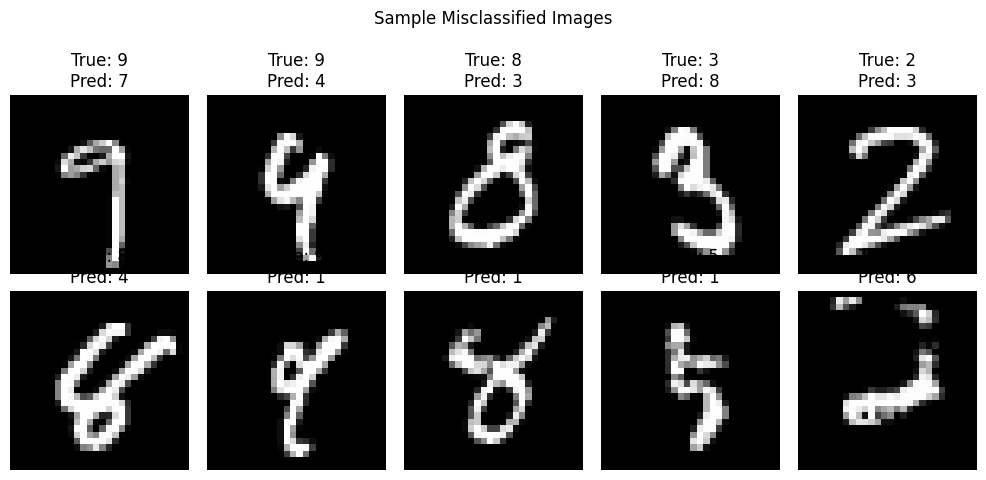

In [18]:
# Identify which digits the model struggles with the most
# Calculate per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Find the least accurate classes
least_accurate_classes = np.argsort(class_accuracies)[:3] # Top 3 struggling digits

print("Model struggles most with the following digits (least accurate):")
for digit in least_accurate_classes:
    print(f"Digit {digit}: Accuracy {class_accuracies[digit]:.4f}")

# Optionally, display some misclassified images
print("\nExamples of misclassified digits:")

misclassified_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(10, 5))
for i, bad_index in enumerate(np.random.choice(misclassified_indices, 10, replace=False)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true[bad_index]}\nPred: {y_pred[bad_index]}")
    plt.axis('off')
plt.suptitle('Sample Misclassified Images')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [19]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Original x_train shape: {x_train.shape}")
print(f"Original y_train shape: {y_train.shape}")
print(f"Original x_test shape: {x_test.shape}")
print(f"Original y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original y_train shape: (60000,)
Original x_test shape: (10000, 28, 28)
Original y_test shape: (10000,)


In [3]:
# Normalize image pixel values to be between 0 and 1
# Reshape the images to have a single channel (grayscale)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255

print(f"Normalized x_train shape: {x_train.shape}")
print(f"Normalized x_test shape: {x_test.shape}")

Normalized x_train shape: (60000, 28, 28, 1)
Normalized x_test shape: (10000, 28, 28, 1)


In [4]:
# Convert labels into one-hot encoded format
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(f"One-hot encoded y_train shape: {y_train.shape}")
print(f"One-hot encoded y_test shape: {y_test.shape}")

One-hot encoded y_train shape: (60000, 10)
One-hot encoded y_test shape: (10000, 10)


### Display Sample Images

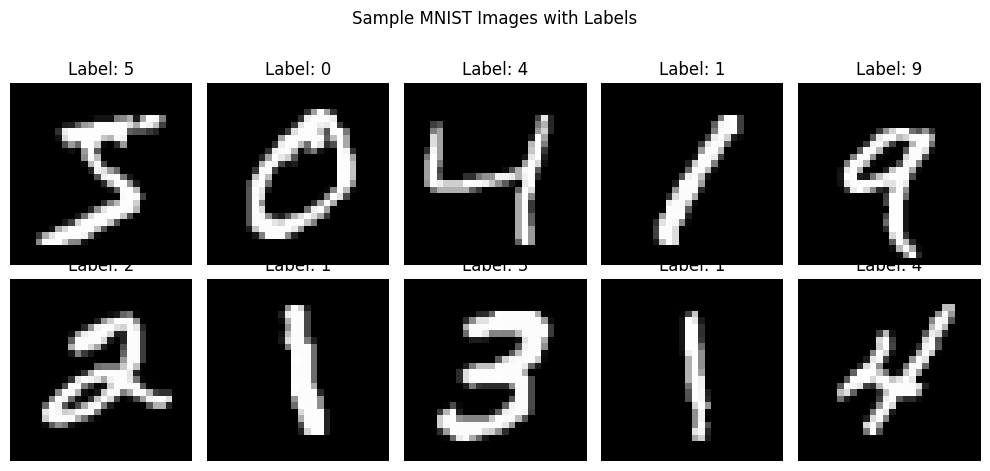

In [5]:
# Display sample images with their corresponding labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    # Convert one-hot encoded label back to integer for display
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Sample MNIST Images with Labels')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 2. Build a Fully Connected Neural Network

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Define a sequential model
model = Sequential([
    # Flatten the 28x28 input images into a single vector of 784 elements
    Flatten(input_shape=(28, 28, 1)),
    # Add a first hidden layer with 128 neurons and ReLU activation
    Dense(128, activation='relu'),
    # Add a second hidden layer with 64 neurons and ReLU activation
    Dense(64, activation='relu'),
    # Add an output layer with 10 neurons (for 10 classes) and Softmax activation
    # Softmax is used for multi-class classification to output probabilities
    Dense(10, activation='softmax')
])

# Compile the model
# Optimizer: 'adam' is a popular choice for many tasks
# Loss function: 'categorical_crossentropy' for one-hot encoded labels
# Metrics: 'accuracy' to monitor classification performance
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Neural Network

In [20]:
# IMPORTANT: If you encounter NameErrors (e.g., 'x_train' not defined),
# please ensure all cells above this one have been run successfully.

# Train the neural network
# Fit the model to the training data for 10 epochs
# Use the test set as validation data to track performance during training
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

print("\nTraining complete.")

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9941 - loss: 0.0169 - val_accuracy: 0.9747 - val_loss: 0.1159
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9943 - loss: 0.0162 - val_accuracy: 0.9789 - val_loss: 0.0989
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9792 - val_loss: 0.0987
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9960 - loss: 0.0123 - val_accuracy: 0.9795 - val_loss: 0.1110
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9959 - loss: 0.0127 - val_accuracy: 0.9797 - val_loss: 0.1037
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9964 - loss: 0.0112 - val_accuracy: 0.9783 - val_loss: 0.1164
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9960 - loss: 0.0120 - val_accuracy: 0.9782 - val_loss: 0.1118
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9972 - loss: 0.0085 -

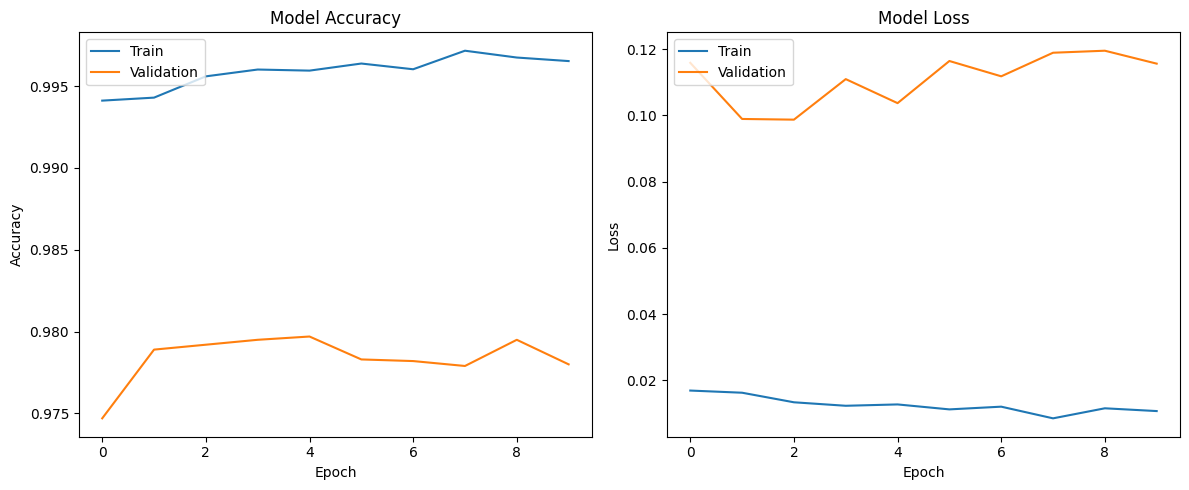

In [21]:
# Observe the loss and accuracy trends over the epochs
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

## 4. Evaluate the Model's Performance

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.1156
Test Accuracy: 0.9780


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


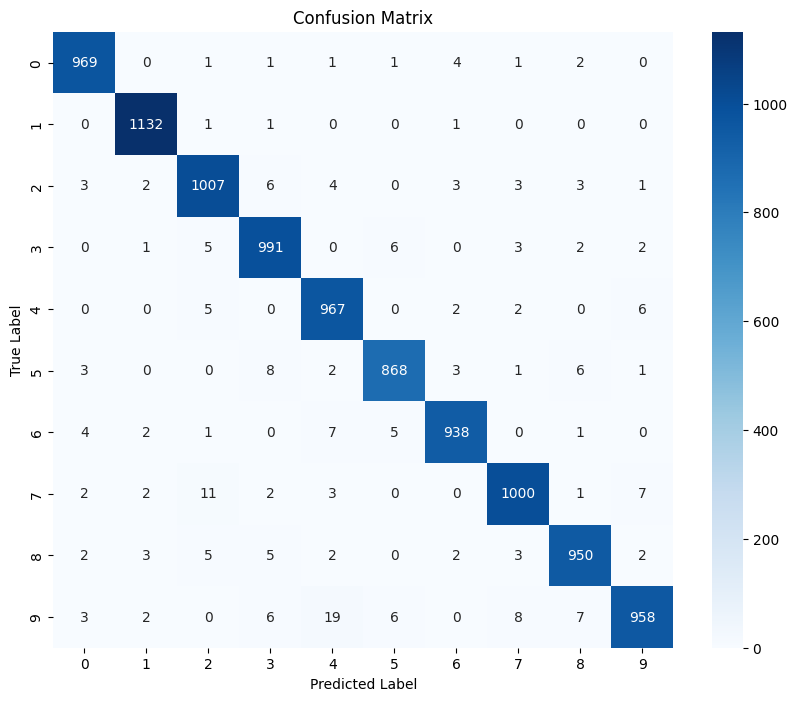

In [23]:
# Make predictions on the test data
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Display a confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Model struggles most with the following digits (least accurate):
Digit 9: Accuracy 0.9495
Digit 7: Accuracy 0.9728
Digit 5: Accuracy 0.9731

Examples of misclassified digits:


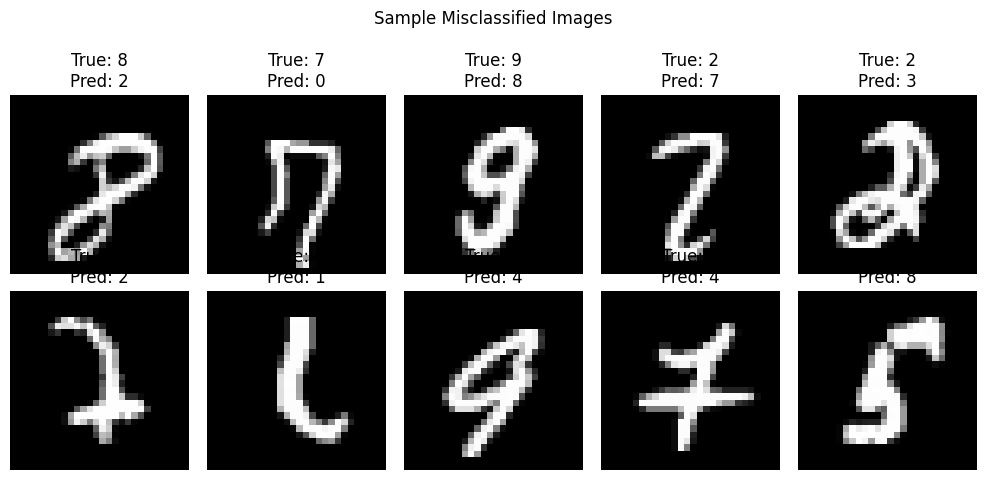

In [24]:
# Identify which digits the model struggles with the most
# Calculate per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1)

# Find the least accurate classes
least_accurate_classes = np.argsort(class_accuracies)[:3] # Top 3 struggling digits

print("Model struggles most with the following digits (least accurate):")
for digit in least_accurate_classes:
    print(f"Digit {digit}: Accuracy {class_accuracies[digit]:.4f}")

# Optionally, display some misclassified images
print("\nExamples of misclassified digits:")

misclassified_indices = np.where(y_true != y_pred)[0]

plt.figure(figsize=(10, 5))
for i, bad_index in enumerate(np.random.choice(misclassified_indices, 10, replace=False)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"True: {y_true[bad_index]}\nPred: {y_pred[bad_index]}")
    plt.axis('off')
plt.suptitle('Sample Misclassified Images')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()